The goal of this project  is  simple to predict whether a hotel booking will be canceled or not using machine learning models and 
identify the factors that influence cancellations.

In [1]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np,matplotlib.pyplot as plt,seaborn as sns,pandas as pd

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
df=pd.read_csv("hotel_bookings.csv")

In [4]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(119390, 32)

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

for country , agent , company we have missing values lets drop company filling that many values is useless and fill the agent with mode and for country lets use mode to fill values

In [7]:
df=df.drop("company",axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df[['reservation_status', 'reservation_status_date']].head()

,reservation_status,reservation_status_date
0,Check-Out,2015-07-01
1,Check-Out,2015-07-01
2,Check-Out,2015-07-02
3,Check-Out,2015-07-02
4,Check-Out,2015-07-03


Because reservation_status is generated after the booking outcome is known, and reservation_status_date is also post-booking information 
that can leak the target column (is_canceled).

In [10]:
df=df.drop(["reservation_status","reservation_status_date"],axis=1)

In [11]:
df["country"]=df["country"].fillna(df["country"].mode()[0])
df["agent"]= df["agent"].fillna(df["agent"].mode()[0])

In [12]:
df.duplicated().sum()

np.int64(32280)

In [13]:
df=df.drop_duplicates()

In [14]:
df.shape

(87110, 29)

after removing missing values , duplicated rows we are left with 87k rows and 29 columns 

In [15]:
# lets check the target distribution 
df["is_canceled"].value_counts()

is_canceled
0    63345
1    23765
Name: count, dtype: int64

the target column is reasonably balanced 

In [16]:
# lets check for categorical columns for encoding

df.select_dtypes(include="object").columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')

In [17]:
# lets check for unique values 

for col in df.select_dtypes(include="object").columns:
    print(col,":",df[col].nunique())

hotel : 2
arrival_date_month : 12
meal : 5
country : 177
market_segment : 8
distribution_channel : 5
reserved_room_type : 10
assigned_room_type : 12
deposit_type : 3
customer_type : 4


checking unique columns coz:

Few unique categories (2–12) → One-Hot Encoding is fine since it creates only a few new columns.

Many unique categories (177 for country) → One-Hot Encoding would create too many columns, so we use Label Encoding instead.

# label encoding for country column
we cant do one hot encoding for country column coz it would create too many dummy columns

In [18]:
le=LabelEncoder()
df["country"]=le.fit_transform(df["country"])

# one hot encoding for rest of categorical columns

In [19]:
df=pd.get_dummies(df,columns=["hotel","arrival_date_month","meal","market_segment","distribution_channel","reserved_room_type","assigned_room_type","deposit_type","customer_type"],drop_first=True)

pd.get_dummies what it does is it will replace each  categorical columns with new numeric  dummy columns coz ml models cant directly work with categorical columns 

In [20]:
df.shape

(87110, 72)

# EDA

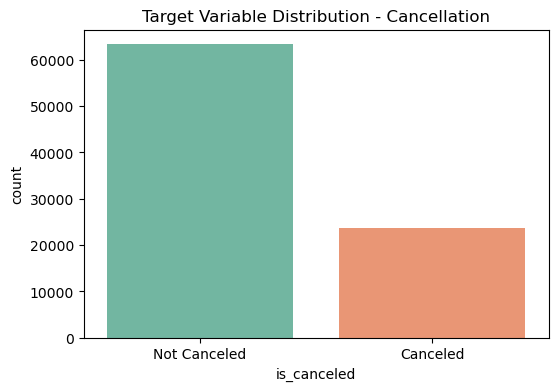

is_canceled
0    72.718402
1    27.281598
Name: proportion, dtype: float64


In [21]:
# 1. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df, hue="is_canceled", legend=False, palette="Set2")
plt.title("Target Variable Distribution - Cancellation")
plt.xticks([0,1], ["Not Canceled", "Canceled"])
plt.show()

print(df["is_canceled"].value_counts(normalize=True)*100)

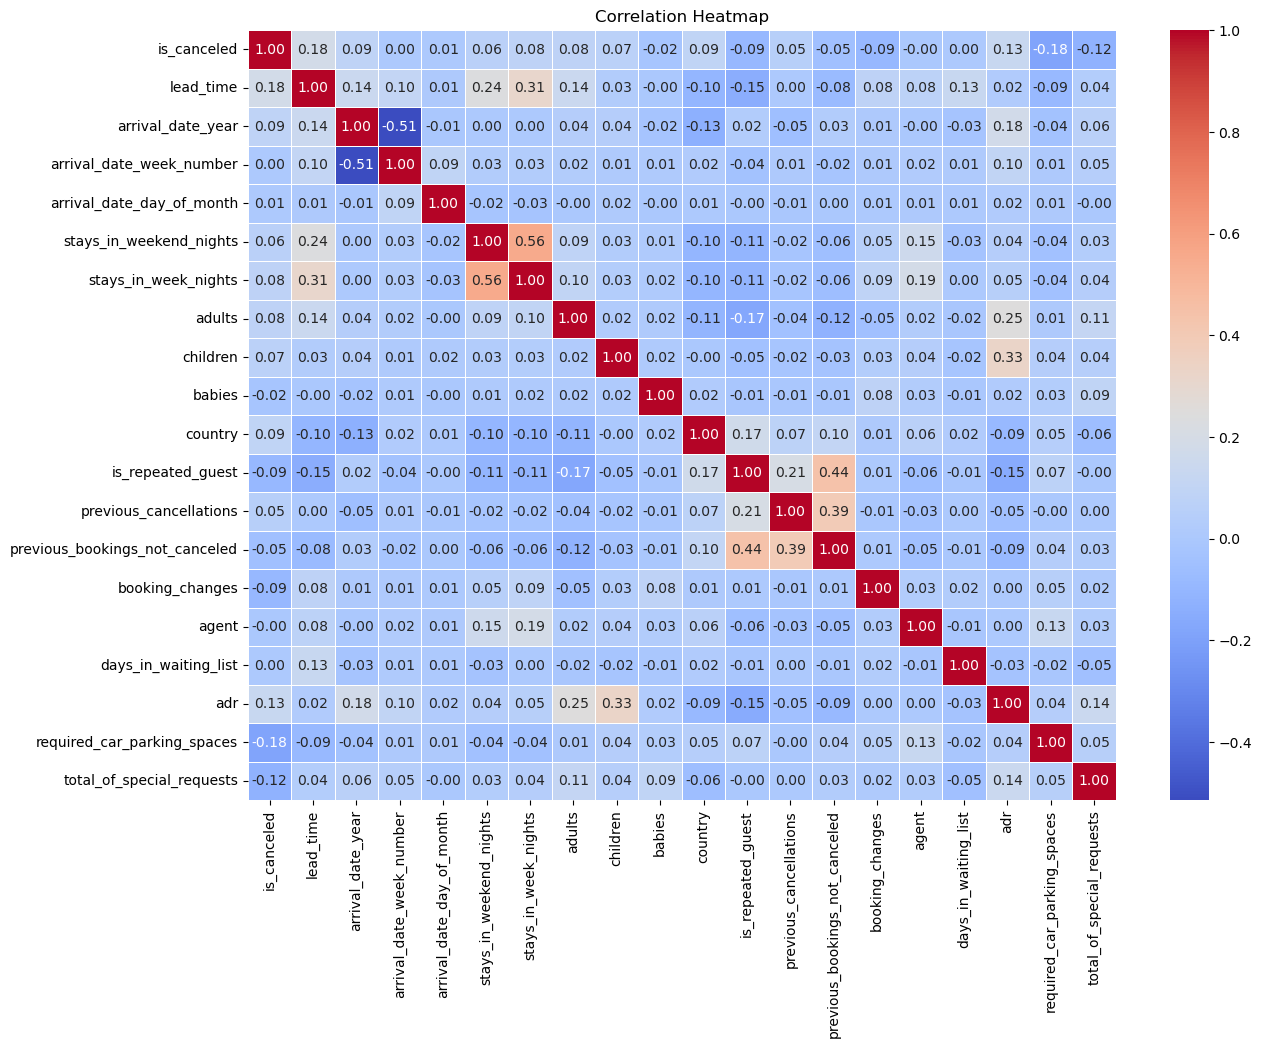

In [22]:
# 2. Correlation Heatmap
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=["int64","float64"])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

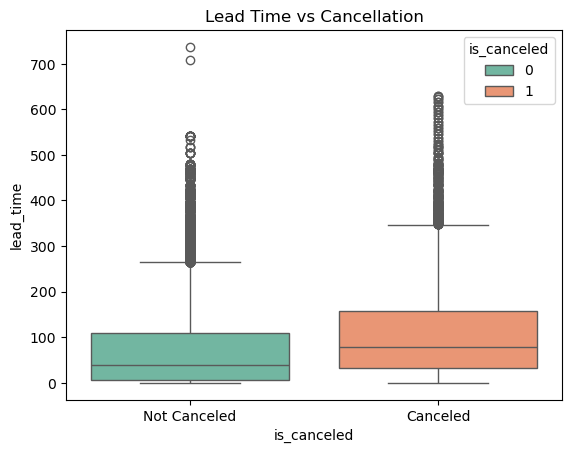

In [23]:
# 3. Lead Time vs Cancellation
sns.boxplot(x="is_canceled", y="lead_time", data=df,hue="is_canceled", palette="Set2")
plt.title("Lead Time vs Cancellation")
plt.xticks([0,1], ["Not Canceled", "Canceled"])
plt.show()

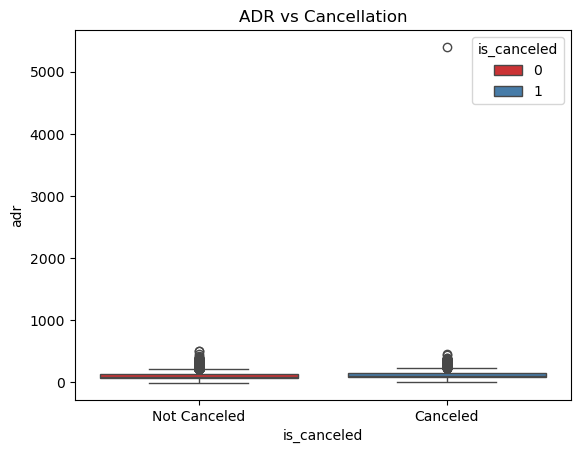

In [24]:
# 4. ADR vs Cancellation
sns.boxplot(x="is_canceled", y="adr", data=df, hue="is_canceled",palette="Set1")
plt.title("ADR vs Cancellation")
plt.xticks([0,1], ["Not Canceled", "Canceled"])
plt.show()

# features and target

In [37]:
x=df.drop("is_canceled",axis=1)
y=df["is_canceled"]

In [38]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [39]:
x_train.shape,x_test.shape

((69688, 71), (17422, 71))

In [40]:
x_train.isnull().sum().sort_values(ascending=False).head()

lead_time                         0
distribution_channel_Undefined    0
reserved_room_type_G              0
reserved_room_type_F              0
reserved_room_type_E              0
dtype: int64

In [41]:
df["children"]=df["children"].fillna(df["children"].mode()[0])
df["children"].isnull().sum()

np.int64(0)

In [42]:
x_train.isnull().sum()

lead_time                        0
arrival_date_year                0
arrival_date_week_number         0
arrival_date_day_of_month        0
stays_in_weekend_nights          0
                                ..
deposit_type_Non Refund          0
deposit_type_Refundable          0
customer_type_Group              0
customer_type_Transient          0
customer_type_Transient-Party    0
Length: 71, dtype: int64

In [43]:
x.isnull().sum().sort_values(ascending=False)

lead_time                         0
distribution_channel_Undefined    0
reserved_room_type_G              0
reserved_room_type_F              0
reserved_room_type_E              0
                                 ..
arrival_date_month_January        0
arrival_date_month_February       0
arrival_date_month_December       0
arrival_date_month_August         0
customer_type_Transient-Party     0
Length: 71, dtype: int64

In [44]:
x.columns[x.isnull().any()]

Index([], dtype='object')

In [45]:
x.isnull().sum().sum()

np.int64(0)

# Feature scaling 

In [46]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [47]:
# create model
dt_model=DecisionTreeClassifier(random_state=42)
knn_model=KNeighborsClassifier(n_neighbors=5)
nb_model=GaussianNB()
light_model=LGBMClassifier()

In [48]:
# train the model
dt_model.fit(x_train,y_train)
knn_model.fit(x_train,y_train)
nb_model.fit(x_train,y_train)
light_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 19105, number of negative: 50583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1311
[LightGBM] [Info] Number of data points in the train set: 69688, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.274150 -> initscore=-0.973665
[LightGBM] [Info] Start training from score -0.973665


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [49]:
# predict the model

import warnings
warnings.filterwarnings("ignore")

dt_y_pred= dt_model.predict(x_test)
knn_y_pred=knn_model.predict(x_test)
nb_y_pred= nb_model.predict(x_test)
light_y_pred= light_model.predict(x_test)

In [50]:
# evaluation metrics

print("accuracy_score for dt : ",accuracy_score(y_test,dt_y_pred))
print("accuracy_score for knn: ",accuracy_score(y_test,knn_y_pred))
print("accuracy_score for nb : ",accuracy_score(y_test,nb_y_pred))
print("accuracy_score for light gbm  : ",accuracy_score(y_test,light_y_pred))

print("confusion_matrix for dt: ",confusion_matrix(y_test,dt_y_pred))
print("confusion_matrix for knn: ",confusion_matrix(y_test,knn_y_pred))
print("confusion_matrix for nb: ",confusion_matrix(y_test,nb_y_pred))
print("confusion_matrix for lightgbm : ",confusion_matrix(y_test,light_y_pred))


print("classification report for dt: ",classification_report(y_test,dt_y_pred))
print("classification report for knn: ",classification_report(y_test,knn_y_pred))
print("classification report or nb: ",classification_report(y_test,nb_y_pred))
print("classification report  for lightgbm : ",classification_report(y_test,light_y_pred))

accuracy_score for dt :  0.794684881184709
accuracy_score for knn:  0.7848697049707267
accuracy_score for nb :  0.7431982550797842
accuracy_score for light gbm  :  0.8460567099070141
confusion_matrix for dt:  [[10892  1870]
 [ 1707  2953]]
confusion_matrix for knn:  [[11142  1620]
 [ 2128  2532]]
confusion_matrix for nb:  [[12708    54]
 [ 4420   240]]
confusion_matrix for lightgbm :  [[11698  1064]
 [ 1618  3042]]
classification report for dt:                precision    recall  f1-score   support

           0       0.86      0.85      0.86     12762
           1       0.61      0.63      0.62      4660

    accuracy                           0.79     17422
   macro avg       0.74      0.74      0.74     17422
weighted avg       0.80      0.79      0.80     17422

classification report for knn:                precision    recall  f1-score   support

           0       0.84      0.87      0.86     12762
           1       0.61      0.54      0.57      4660

    accuracy               


LightGBM is the best model with the highest accuracy, precision, recall, and F1-score.84.61%

Decision Tree is second-best and much simpler to explain.79.47%

KNN performs reasonably but misses more cancellations (lower recall).78.32%

Naive Bayes performs poorly for canceled bookings (recall = 0.05), so it's not suitable here.74.32%
    

for this project lightgbm has achieved the best performances with 84.6% accuracy and F1 score of 0.69for canceled bookings,
making it the selected model for hotel booking cancellation prediction.

# cross validation score 

In [51]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(light_model,x,y,cv=cv,scoring="accuracy")

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19012, number of negative: 50676
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1234
[LightGBM] [Info] Number of data points in the train set: 69688, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.272816 -> initscore=-0.980382
[LightGBM] [Info] Start training from score -0.980382
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19012, number of negative: 50676
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

# Feature Engineering

In [52]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["booking_changes_per_day"] = df["booking_changes"] / (df["total_stay"] + 1)
df["adr_per_guest"] = df["adr"] / (df["total_guests"] + 1)

# hyperparameter tuning 

In [53]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {"n_estimators": [100, 200, 300, 500],"learning_rate": [0.01, 0.05, 0.1, 0.2],"max_depth": [3, 5, 7, 10, -1],"num_leaves": [20, 31, 50, 70],
    "min_child_samples": [10, 20, 30, 50],"subsample": [0.8, 0.9, 1.0],"colsample_bytree": [0.8, 0.9, 1.0]}

random_search = RandomizedSearchCV(estimator=LGBMClassifier(random_state=42),param_distributions=param_dist,n_iter=20,cv=5,scoring="accuracy",n_jobs=-1,random_state=42)


random_search.fit(x_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

[LightGBM] [Info] Number of positive: 19105, number of negative: 50583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1311
[LightGBM] [Info] Number of data points in the train set: 69688, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.274150 -> initscore=-0.973665
[LightGBM] [Info] Start training from score -0.973665
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [ ]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
feature_importance = pd.DataFrame({"Feature": x.columns,"Importance": best_model.feature_importances_}).sort_values( "Importance",ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(12,8))
sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

Lead Time is the most important factor — bookings made far in advance are more likely to be canceled.

ADR (Average Daily Rate) strongly influences cancellations — higher-priced bookings tend to have different cancellation behavior.

Country matters — cancellation patterns vary by customer origin.

Arrival Date Week Number affects cancellations, indicating seasonality.

Arrival Month is important, showing that cancellations change across different times of the year.

In [ ]:
x.columns.tolist()

In [ ]:
import joblib

joblib.dump(best_model, "hotel_cancellation_model.pkl")

The LightGBM model identified Lead Time, ADR, Country, Arrival Week Number, and Arrival Month as the most influential features in predicting hotel booking cancellations, highlighting the importance of booking timing, pricing, customer geography, and seasonal trends.